In [1]:
from matplotlib import pyplot as plt
import sys
sys.path.append('..')
from func import custom_loss
import nn4n.nn
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Load the input and the label
# ===========================================================================================

load_data_type = '2WSMS_mask_vel-2-3'
load_dir = f'../../data/'
data = np.load(f'{load_dir}/{load_data_type}.npy', allow_pickle=True).item()

train_inputs = torch.tensor(data[f'train_inputs'], dtype=torch.float32).to(device)
train_labels = torch.tensor(data[f'train_labels'], dtype=torch.float32).to(device)

# Create DataLoader for training and testing
train_dataset = TensorDataset(train_inputs, train_labels)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

In [3]:
# Initialise the RNN
# ===========================================================================================
num_neuron = 512

model_cfg = {
            "input_dim":    train_inputs.shape[2],
            "hidden_dim":   num_neuron,
            'output_dim':   train_inputs.shape[2],
            "alpha":        0.01,
            "learn_alpha":  False,
            "preact_noise": 0.1,
            "postact_noise":0.1
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # input_dim=model_cfg["hidden_dim"],
                                    # output_dim=model_cfg["hidden_dim"],
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)

optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

In [4]:
# Train the RNN
# ===========================================================================================
    
from tqdm import tqdm

rnn.train()

losses = []

for epoch in tqdm(range(10000)):

    for batch_inputs, batch_labels in train_loader:
        
        optimizer.zero_grad()
        batch_outputs, batch_hidden = rnn(batch_inputs)
        
        # loss = criterion(batch_outputs, batch_labels)
        loss, loss1, loss2 = custom_loss(batch_outputs, batch_labels, batch_hidden, lambda_mse=1, lambda_r=0.0001
                           ) 
        loss.backward()
        
        optimizer.step()
        losses.append(loss.item())
        
    if epoch % 100 == 0:
        print(f'Epoch {epoch} Loss {loss.item()}')
        print(loss1, loss2)
    # if loss1 < 0.02:
    #     print("Early stopping due to low MSE loss.")
    #     break
    if  losses[-1] < 0.1 and abs(losses[-1] - losses[-50]) < 1e-4: # len(losses) > 50  :
        print("Early stopping due to convergence.")
        break
    
print("Training complete.")

  0%|          | 2/10000 [00:00<37:08,  4.49it/s]  

Epoch 0 Loss 4.5488409996032715
tensor(4.3922, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.1567, device='cuda:0', grad_fn=<MulBackward0>)


  1%|          | 102/10000 [00:11<17:39,  9.34it/s]

Epoch 100 Loss 0.7770785093307495
tensor(0.7444, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0327, device='cuda:0', grad_fn=<MulBackward0>)


  2%|▏         | 202/10000 [00:21<17:31,  9.32it/s]

...

Epoch 9800 Loss 0.1424625962972641
tensor(0.1192, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0233, device='cuda:0', grad_fn=<MulBackward0>)


 99%|█████████▉| 9902/10000 [17:43<00:10,  9.35it/s]

Epoch 9900 Loss 0.14269469678401947
tensor(0.1197, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0230, device='cuda:0', grad_fn=<MulBackward0>)


100%|██████████| 10000/10000 [17:53<00:00,  9.31it/s]

Training complete.


In [5]:
# Test the RNN
# ===========================================================================================

test_inputs = torch.tensor(data['test_inputs'], dtype=torch.float32).to(device)

rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)

test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
print('test outputs:',  type(test_outputs),  test_outputs.shape)
print('hidden states:', type(hidden_states), hidden_states.shape)

test outputs: <class 'numpy.ndarray'> (50, 100, 100)
hidden states: <class 'numpy.ndarray'> (50, 100, 512)


In [ ]:
# # Plot the test outputs vs the test labels
# test_inputs = data['test_inputs']
# test_labels = data['test_labels']
# test_outputs = data['test_outputs_512']
# fig, ax = plt.subplots(1,2, figsize=(10,5))
# for i in range(3):
#     ax[1].plot(test_labels[0,:,i], label='label', color=f'C{i}')
#     ax[1].plot(test_outputs[0,:,i], label='Pred', linestyle='dotted', color=f'C{i}')
#     ax[0].plot(test_inputs[0,:,i], label='Input', linestyle='--', color=f'C{i}')
# ax[0].legend()

KeyError: 'test_outputs_512'

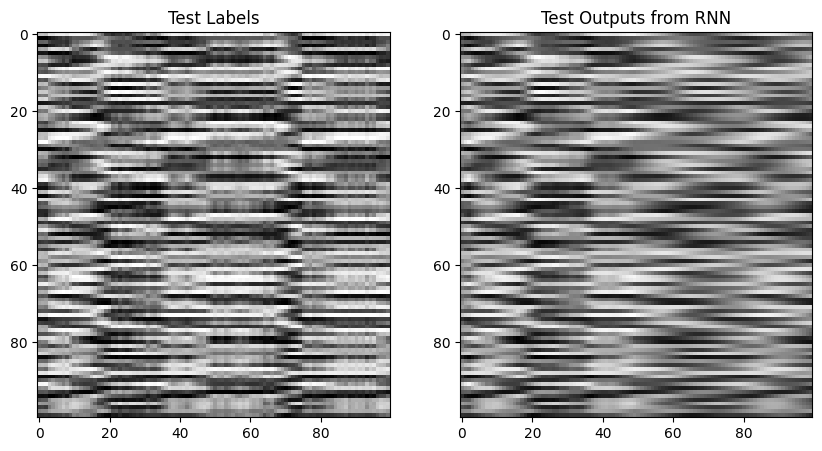

In [7]:
# Plot the test outputs vs the test labels
test_labels = data['test_labels']
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(test_labels[0].T, aspect='auto', cmap='binary')
ax[0].set_title('Test Labels')
ax[1].imshow(test_outputs[0].T, aspect='auto', cmap='binary')
ax[1].set_title('Test Outputs from RNN')
plt.show()

### Save the model weights and data output

In [10]:
model_dir = '../../model/'
import os
os.makedirs(model_dir, exist_ok=True)
torch.save(rnn.state_dict(), f'{model_dir}/{load_data_type}.pth')

In [ ]:
data[f'loss_{model_cfg["hidden_dim"]}'] = losses
data[f'test_outputs_{model_cfg["hidden_dim"]}'] = test_outputs
data[f'hidden_states_{model_cfg["hidden_dim"]}'] = hidden_states
print(data.keys())

dict_keys(['train_inputs', 'train_labels', 'test_inputs', 'test_labels', 'arena_map', 'train_traj', 'test_traj', 'loss_512', 'test_outputs_512', 'hidden_states_512'])


In [12]:
print(f'{load_dir}/{load_data_type}.npy')
np.save(f'{load_dir}/{load_data_type}.npy', data, allow_pickle=True)

../../data//2WSMS_mask_vel-2-3.npy
